Here we're trying to determine the coherent energy as a function of frequency, to estimate the spatial distribution of slip in an LFE family.

In [1]:
import os,sys,glob
sys.path.insert(0,r'C:\Users\jhawt\Documents\FILES\PYFILES\LFEFocMech')
sys.path.insert(0,r'C:\Users\jhawt\Documents\FILES\PYFILES\Tremor')
sys.path.insert(0,r'C:\Users\jhawt\Documents\FILES\PYFILES\General')
sys.path.insert(0,r'C:\Users\jhawt\Documents\FILES\PYFILES\SeisProc')

In [2]:
import numpy as np
import obspy
import lfeanalysis
import matplotlib.pyplot as plt
from importlib import reload
reload(lfeanalysis)

<module 'lfeanalysis' from 'C:\\Users\\jhawt\\Documents\\FILES\\PYFILES\\LFEFocMech\\lfeanalysis.py'>

### 1. Load and prepare the data

This reads in the data and does some grouping by time.

In [3]:
# as before, we need to initialize an analysis object
lf=lfeanalysis.lfanalyse(fnum=74)

# and load in the detections and waveforms
lf.load_prep_data(flm=[1,18],single_norm=False)

Reading data
Normalizing data
Filtering data


### 2. Stack

In [5]:
# stack for each group
lf.stack_by_group()

# and pick arrival times
lf.pick_stacks(minsnr=10)

### 3. Project along ray paths

This is optional, but we may want to analyse radial and transverse S waves instead of E, N, Z.

In [6]:
# read the station locations
lf.read_station_locations()

C:\Users\jhawt\PROGRAMS\miniconda3\envs\strain\lib\site-packages\obspy\core\inventory\network.py:324: UserWarning: Found more than one matching channel metadata. Returning first.
  warnings.warn(msg)


In [7]:
# and compute the station location relative to the LFE family we're working with
print('LFE longitude, latitude, depth (in km)',lf.floc)
lf.relative_station_locations()


LFE longitude, latitude, depth (in km) [-123.7003   48.1192   29.09  ]


### 4. Compute station amplitude corrections

When we compute the coherent energy, we will use the amplitude information, so it's important that the stacks be correctly scaled.

In [8]:
# all the cross-correlations
lf.xc_with_stack()

# and amplitude normalizations
lf.normalize_amplitudes()

C:\Users\jhawt\Documents\FILES\PYFILES\LFEFocMech\lfeanalysis.py:3008: RuntimeWarning: Mean of empty slice
  xcbystat=np.nanmean(self.xc,axis=3)
C:\Users\jhawt\Documents\FILES\PYFILES\LFEFocMech\lfeanalysis.py:3009: RuntimeWarning: Mean of empty slice
  xcmean=np.nanmean(xcbystat,axis=2)
C:\Users\jhawt\PROGRAMS\miniconda3\envs\strain\lib\site-packages\numpy\lib\nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,


### 5. Compute coherent energy

In [14]:
reload(lfeanalysis)
lf=lfeanalysis.lfanalyse(lfi=lf)
lf.compute_coherent_energy(data_window=[-1,1],stack_window=[0,4])

In [18]:
# This calculation computes various energies
print('Energy is calculated for {:d} LFEs and {:d} frequencies'.format(lf.tms.size,lf.freq_energy.size))
print('Energy is calculated for two channels: ',lf.energy_channels)

print('\nWe have several energies')
print('Total energy in the window :',lf.total_energy.shape)
print('Total energy in the noise window :',lf.noise_energy.shape)

print('\nEnergy that is coherent across stations',lf.coherent_energy.shape)
print('Energy that is coherent across channels/components, averaged over stations',lf.component_energy.shape)

Energy is calculated for 3857 LFEs and 41 frequencies
Energy is calculated for two channels:  ['R' 'T']

We have several energies
Total energy in the window : (41, 3857, 2)
Total energy in the noise window : (41, 3857, 2)

Energy that is coherent across stations (41, 3857, 2)
Energy that is coherent across channels/components, averaged over stations (41, 3857)


Bootstrapping
Plotting


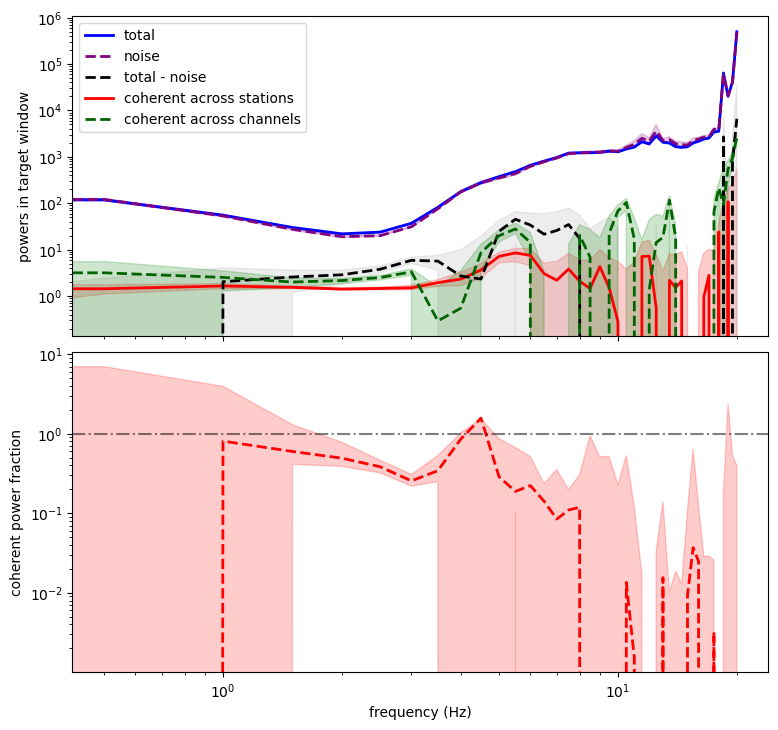

In [21]:
# we can plot these powers as a function of frequency
# the shading indicates the range of values obtained by bootstrapping the 
# LFEs included in the average
lf.plot_coherent_energy(prc=0.9,kcomp=[0,1])

In this particular case it seems like the coherence drops off quite quickly.  That could be because the LFEs are spatially large, because the templates aren't great, or because other LFEs are interfering.